In [1]:
%load_ext autoreload
%autoreload 2

from utils import make_spikes_responses_df
import os 
import numpy as np
import pandas as pd
import yaml
import shutil
from utils import read_pattern_json, preprocess_pattern_stimulations_df

# =====================
# Load Configuration
# =====================
CONFIG_PATH = "config.yaml"  # Change this to use a different config file

with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

# Extract data settings from config
datadir = cfg['datadir']
problematic_neurons = cfg['problematic_neurons']

spikes_df = make_spikes_responses_df(os.path.join(datadir, "spkVecs.npy"))
spikes_df.head(5)

# optionally, drop neurons with very high firing rates that may be multi-unit activity or artifacts
spikes_df = spikes_df[~spikes_df['neuron_id'].isin(problematic_neurons)]
print (spikes_df['neuron_id'].nunique(), " unique neurons recorded after dropping problematic neurons")
pattern_registrations_path = os.path.join(datadir, "pattern_registrations.pkl")
pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(pattern_registrations_path))
spikes_df['timestamp'] -= min_pattern_timestamp
pattern_df.head(30)

63  unique neurons recorded after dropping problematic neurons


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_flag_start_timestamp,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial,pattern_end_timestamp,pattern_duration
0,0,2033,4033,1.0,0,0,10,81.0,-1.0,True,1,61751,61751
1,0,2033,4033,1.0,0,0,10,89.0,0.0,True,1,61751,61751
2,1,4064,4033,1.0,0,0,10,7.0,2.0,True,1,61751,61751
3,1,4064,4033,1.0,0,0,10,4.0,0.0,True,1,61751,61751
4,1,4064,4033,1.0,0,0,10,34.0,0.0,True,1,61751,61751
5,2,5964,4033,1.0,0,0,10,3.0,-1.0,True,1,61751,61751
6,2,5964,4033,1.0,0,0,10,4.0,0.0,True,1,61751,61751
7,3,7896,4033,1.0,0,0,10,63.0,-1.0,True,1,61751,61751
8,3,7896,4033,1.0,0,0,10,70.0,0.0,True,1,61751,61751
9,4,9855,4033,1.0,0,0,10,14.0,1.0,True,1,61751,61751


In [2]:
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = spikes_df['neuron_id'].unique()
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}
spiking_neurons.sort()

print (f"Total unique stimulation channels used: {len(channel_to_index)}")
print ("Stimulation channel names: ", [str(int(k)) for k in sorted(channel_to_index.keys())])

print (f"Total spiking neurons recorded: {len(spiking_neurons)}")
print ("Spiking neuron names: ", spiking_neurons)


Total unique stimulation channels used: 42
Stimulation channel names:  ['1', '2', '3', '4', '7', '9', '10', '12', '14', '20', '22', '30', '33', '34', '36', '37', '39', '41', '44', '46', '47', '49', '54', '56', '60', '63', '64', '66', '67', '69', '70', '71', '72', '73', '81', '82', '88', '89', '90', '92', '93', '95']
Total spiking neurons recorded: 63
Spiking neuron names:  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  20  21  22  23 100 101 102 103 105 106 107 108 109 110 111 200 202
 203 204 205 206 207 208 209 210 212 213 214 301 302 303 304 305 306 307
 308 309 313 314 315 316 317 318 319]


In [3]:
from utils import trial_breakout_spikes_and_patterns

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = trial_breakout_spikes_and_patterns(
    spikes_df,
    pattern_df,
    channel_to_index,
    spiking_neurons=spiking_neurons,
    spiking_neuron_to_index=spiking_neuron_to_index,
    
)

# Note pattern stims and polarities are keyed by pattern_name while spike_responses and timing_to_pattern are keyed by timing index. timing_to_pattern connects timing index to pattern name in case you need it.
# spikes are recorded in 1 ms resolution in this spikes_responses

print(f"Total unique patterns: {len(pattern_stims)}")
print(f"Total trials (spike responses): {len(spike_responses)}")
print(f"Oracle trials: {unique_trials['is_oracle'].sum()}")
print(f"Non-oracle trials: {(~unique_trials['is_oracle']).sum()}")

Total unique patterns: 4050
Total trials (spike responses): 5000
Oracle trials: 1000
Non-oracle trials: 4000


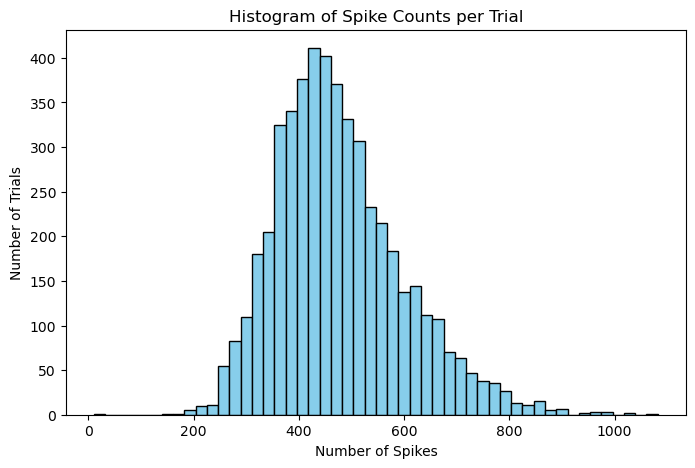

In [4]:
# Histogram of spikes per trial
import matplotlib.pyplot as plt
spike_counts_per_trial = [resp.sum() for resp in spike_responses.values()]
plt.figure(figsize=(8,5))
plt.hist(spike_counts_per_trial, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Spike Counts per Trial')
plt.xlabel('Number of Spikes')
plt.ylabel('Number of Trials')
plt.show()

In [5]:
# Example: Plot stimulation pattern for a specific pattern (colored by polarity)
from viz import plot_oracle_pattern_average_responses, plot_stimulation_polarity_timeseries
for pattern in pattern_df['pattern_name'].unique()[:3]:
    pattern_name = (int(pattern))
    plot_stimulation_polarity_timeseries(pattern_stims, pattern_polarities, pattern_name=pattern_name, savepath=os.path.join(datadir, 'stim_viz/'))
plot_oracle_pattern_average_responses(unique_trials, spike_responses, spiking_neurons, savepath=os.path.join(datadir, 'oracle_pattern_averages_bin_fixed/'), plot_duration=2000, bin_size=60)

Pattern 4033: stim shape (42, 600), polarity shape (42, 600)
Pattern 4017: stim shape (42, 600), polarity shape (42, 600)
Pattern 4028: stim shape (42, 600), polarity shape (42, 600)


2026-02-02 09:09:36,764 - INFO - ==================================================
2026-02-02 09:09:36,765 - INFO - Experiment run directory: results/binned_2026-02-02_09-09-36
2026-02-02 09:09:36,765 - INFO - Config file: config.yaml (copied to results/binned_2026-02-02_09-09-36/config.yaml)
2026-02-02 09:09:36,765 - INFO - Inference mode: False
2026-02-02 09:09:36,766 - INFO - Random seed: 42
2026-02-02 09:09:36,766 - INFO - ==================================================
2026-02-02 09:09:36,767 - INFO - Total trials: 5000
2026-02-02 09:09:36,777 - INFO - Oracle trials: 1000 (50 patterns × 10 trials)
2026-02-02 09:09:36,777 - INFO - Sample trials: 4000
2026-02-02 09:09:36,779 - INFO - Train: 3400, Val: 600, Test: 1000
2026-02-02 09:09:36,779 - INFO - Dataset config: bin_size=10ms, n_input_bins=1, n_output_bins=6, output_offset=0
2026-02-02 09:09:52,635 - INFO - BinnedStimSpikeDataset initialized:
2026-02-02 09:09:52,638 - INFO -   bin_size_ms=10, n_input_bins=1, n_output_bins=6
2

(<Figure size 1600x500 with 3 Axes>,
 array([<Axes: title={'center': 'Binary Spike Distribution\n(bin_size=10ms, n_output_bins=6)'}, xlabel='Spike Bin Category', ylabel='Frequency'>,
        <Axes: title={'center': 'Per-Sample Sparsity (across 63 neurons)'}, xlabel='% Neurons with Zero Spikes', ylabel='Number of Samples'>,
        <Axes: title={'center': 'Average Spike Rate per Neuron (± SEM, n=3400 trials)'}, xlabel='Neuron Index', ylabel='Mean Spikes per 10ms Bin'>],
       dtype=object))

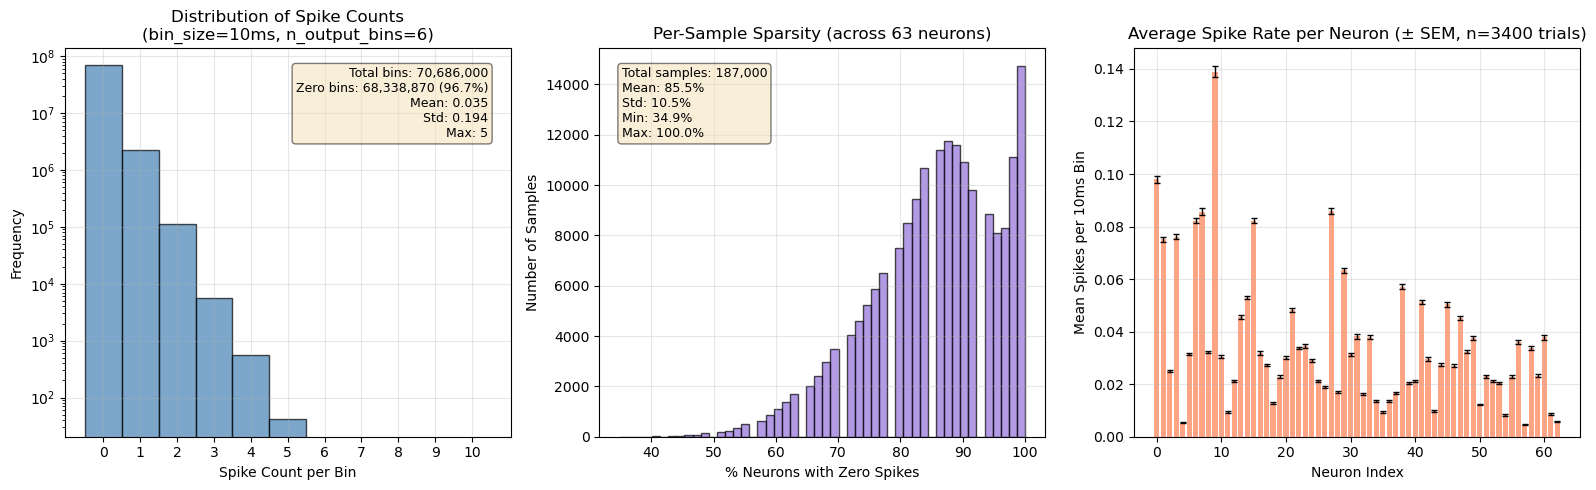

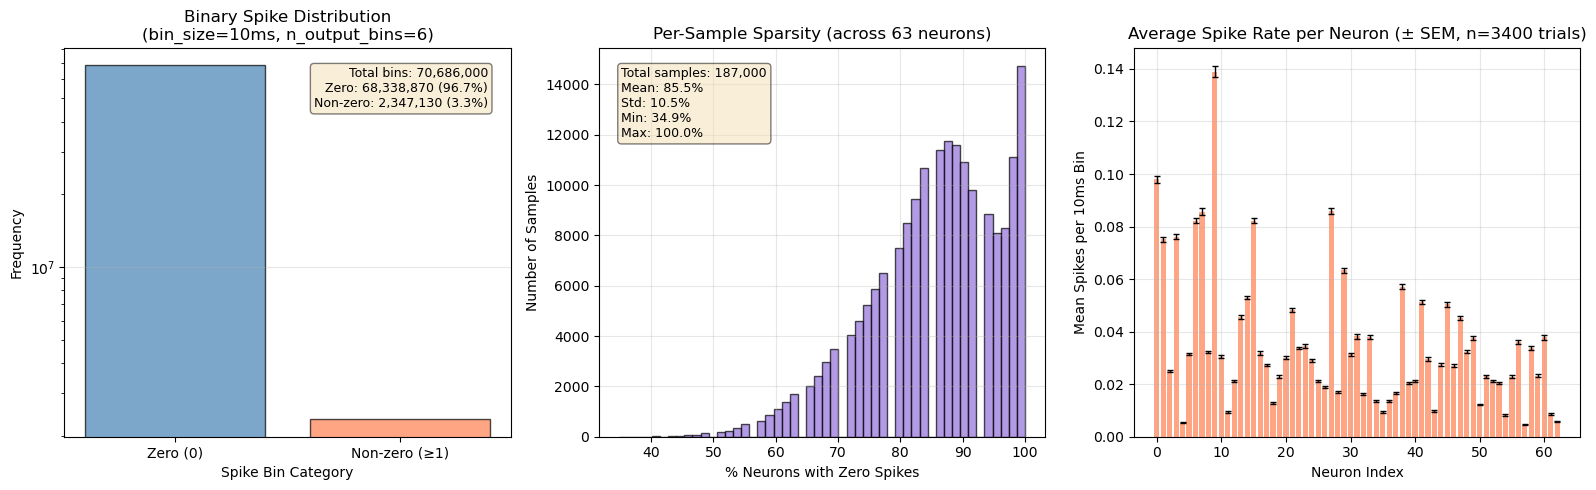

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from datetime import datetime
import json
import logging

from utils import BinnedStimSpikeDataset, DELAY_MODE_TO_INDEX, NO_STIM_INDEX, NUM_STIM_LEVELS
from models import StimToSpikeMLP, StimToSpikeCNN
from viz import plot_spike_bin_distribution

# =====================
# Extract Configuration Values
# =====================
INFERENCE_MODE = cfg['inference_mode']
ARTIFACT_PATH = cfg['artifact_path']
SEED = cfg['seed']
SPLIT_MODE = cfg['split_mode']

# Dataset Configuration
BIN_SIZE_MS = cfg['bin_size_ms']
BIN_SIZE_FRAMES = BIN_SIZE_MS * 30  # ASSUME 30 kHz, so each frame is around 30 milliseconds
N_INPUT_BINS = cfg['n_input_bins']
N_OUTPUT_BINS = cfg['n_output_bins']
OUTPUT_OFFSET = cfg['output_offset']
MAX_TIME_MS = cfg['max_time_ms']
BATCH_SIZE = cfg['batch_size']

# Create timestamped results folder for this run
if INFERENCE_MODE and ARTIFACT_PATH:
    RUN_DIR = ARTIFACT_PATH
else:
    timestamp = datetime.now().strftime("binned_%Y-%m-%d_%H-%M-%S")
    RUN_DIR = os.path.join("results", timestamp)
    os.makedirs(RUN_DIR, exist_ok=True)

# =====================
# Save a copy of the config file to the run directory
# =====================
config_save_path = os.path.join(RUN_DIR, 'config.yaml')
shutil.copy(CONFIG_PATH, config_save_path)

# =====================
# Setup Logging
# =====================
# Remove any existing handlers to avoid duplicate logs
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_file = os.path.join(RUN_DIR, "experiment.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()  # Also output to console
    ]
)
logger = logging.getLogger(__name__)

logger.info(f"{'='*50}")
logger.info(f"Experiment run directory: {RUN_DIR}")
logger.info(f"Config file: {CONFIG_PATH} (copied to {config_save_path})")
logger.info(f"Inference mode: {INFERENCE_MODE}")
logger.info(f"Random seed: {SEED}")
if INFERENCE_MODE:
    logger.info(f"Loading artifacts from: {ARTIFACT_PATH}")
logger.info(f"{'='*50}")

# =====================
# Create Train/Val/Test Splits
# =====================
all_timing_indices = list(spike_responses.keys())
logger.info(f"Total trials: {len(all_timing_indices)}")

# Get unique trials info for splitting
unique_trials_info = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()

if SPLIT_MODE == 'oracle':
    oracle_timing_indices = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    sample_timing_indices = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    
    logger.info(f"Oracle trials: {len(oracle_timing_indices)} (50 patterns × 10 trials)")
    logger.info(f"Sample trials: {len(sample_timing_indices)}")
    
    test_indices = oracle_timing_indices
    train_indices, val_indices = train_test_split(sample_timing_indices, test_size=0.15, random_state=SEED)
    
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

elif SPLIT_MODE == 'random':
    train_val_indices, test_indices = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.176, random_state=SEED)
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

logger.info(f"Dataset config: bin_size={BIN_SIZE_MS}ms, n_input_bins={N_INPUT_BINS}, "
            f"n_output_bins={N_OUTPUT_BINS}, output_offset={OUTPUT_OFFSET}")

# Create datasets
train_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    train_indices, bin_size_ms=BIN_SIZE_MS, n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, max_time_ms=MAX_TIME_MS, output_offset=OUTPUT_OFFSET,
    logger=logger
)
val_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    val_indices, bin_size_ms=BIN_SIZE_MS, n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, max_time_ms=MAX_TIME_MS, output_offset=OUTPUT_OFFSET,
    logger=logger
)
test_dataset = BinnedStimSpikeDataset(
    pattern_df, spike_responses, channel_to_index, timing_to_pattern,
    test_indices, bin_size_ms=BIN_SIZE_MS, n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS, max_time_ms=MAX_TIME_MS, output_offset=OUTPUT_OFFSET,
    logger=logger
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

logger.info(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
logger.info(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

n_stim_channels = train_dataset.n_channels
n_neurons = train_dataset.n_neurons
logger.info(f"Number of stimulation channels: {n_stim_channels}")
logger.info(f"Number of recorded neurons: {n_neurons}")

# Verify sample shapes
sample_x, sample_y = train_dataset[0]
logger.info(f"Sample X shape: {sample_x.shape} (n_channels, n_input_bins)")
logger.info(f"Sample Y shape: {sample_y.shape} (n_neurons, n_output_bins)")

# =====================
# Device Setup
# =====================
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
    logger.info(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = 'Apple Silicon (MPS)'
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
    logger.info(f"Using Apple Silicon MPS acceleration")
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    logger.info(f"Using CPU")

logger.info(f"PyTorch version: {torch.__version__}")
logger.info(f"Device: {device}")

# Save experiment config (JSON summary)
config = {
    'timestamp': datetime.now().isoformat(),
    'config_file': CONFIG_PATH,
    'artifact_path': ARTIFACT_PATH,
    'inference_mode': INFERENCE_MODE,
    'seed': SEED,
    'split_mode': SPLIT_MODE,
    'bin_size_ms': BIN_SIZE_MS,
    'n_input_bins': N_INPUT_BINS,
    'n_output_bins': N_OUTPUT_BINS,
    'output_offset': OUTPUT_OFFSET,
    'max_time_ms': MAX_TIME_MS,
    'batch_size': BATCH_SIZE,
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
    'n_stim_channels': n_stim_channels,
    'n_neurons': n_neurons,
    'device': str(device),
    'device_name': device_name,
    'pytorch_version': torch.__version__,
}

with open(os.path.join(RUN_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

logger.info(f"Saved experiment config to {os.path.join(RUN_DIR, 'config.json')}")
plot_spike_bin_distribution(train_dataset, mode='counts', max_count=10, savepath=os.path.join(RUN_DIR, 'train_spike_distribution_counts.png'), logger=logger)
plot_spike_bin_distribution(train_dataset, mode='binary', savepath=os.path.join(RUN_DIR, 'train_spike_distribution_binary.png'), logger=logger)

In [7]:
# =====================
# Initialize Model
# =====================
# Extract model config from config file
MODEL_TYPE = cfg['model_type']
EMBEDDING_DIM = cfg['embedding_dim']
DROPOUT = cfg['dropout']
HIDDEN_DIMS = cfg['hidden_dims']
CONV_CHANNELS = cfg['conv_channels']
KERNEL_SIZES = cfg['kernel_sizes']
FC_DIMS = cfg['fc_dims']
INIT_BIAS = cfg['init_bias']
LINEAR = cfg.get('linear', True)

sparsity_stats = train_dataset.compute_sparsity()
mean_spikes = sparsity_stats['nonzero_bins'] / sparsity_stats['total_bins']

if MODEL_TYPE == 'mlp':
    model = StimToSpikeMLP(
        n_stim_channels=n_stim_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        init_bias=INIT_BIAS,
        linear=LINEAR,
        num_stim_levels=NUM_STIM_LEVELS
    ).to(device)
elif MODEL_TYPE == 'cnn':
    model = StimToSpikeCNN(
        n_stim_channels=n_stim_channels,
        n_neurons=n_neurons,
        n_input_bins=N_INPUT_BINS,
        n_output_bins=N_OUTPUT_BINS,
        embedding_dim=EMBEDDING_DIM,
        conv_channels=CONV_CHANNELS,
        kernel_sizes=KERNEL_SIZES,
        fc_dims=FC_DIMS,
        dropout=DROPOUT,
        init_bias=INIT_BIAS,
        num_stim_levels=NUM_STIM_LEVELS
    ).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Model: {MODEL_TYPE.upper()}")
logger.info(f"  Embedding: {NUM_STIM_LEVELS} categories -> {EMBEDDING_DIM}-dim vectors")
logger.info(f"  Hidden layers: {HIDDEN_DIMS if MODEL_TYPE == 'mlp' else CONV_CHANNELS}")
logger.info(f"  Dropout: {DROPOUT}")
logger.info(f"  Total parameters: {total_params:,}")
logger.info(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")

# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
neuron = 1
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {sample_out[i, neuron, :].cpu().numpy()}")


2026-02-02 09:10:34,286 - INFO - Model: CNN
2026-02-02 09:10:34,286 - INFO -   Embedding: 5 categories -> 32-dim vectors
2026-02-02 09:10:34,287 - INFO -   Hidden layers: [128, 64]
2026-02-02 09:10:34,287 - INFO -   Dropout: 0.2
2026-02-02 09:10:34,288 - INFO -   Total parameters: 196,442
2026-02-02 09:10:34,288 - INFO -   Trainable parameters: 196,442
2026-02-02 09:10:34,462 - INFO - Input shape: torch.Size([128, 42, 1]), dtype: torch.int64
2026-02-02 09:10:34,462 - INFO - Output shape: torch.Size([128, 63, 6])
2026-02-02 09:10:34,463 - INFO - Target shape: torch.Size([128, 63, 6])
2026-02-02 09:10:34,463 - INFO - ✓ Output and target shapes match!
2026-02-02 09:10:34,463 - INFO - Sample model outputs (first batch):
2026-02-02 09:10:34,464 - INFO - Sample 0 target (neuron 4, all output bins): [0. 0. 0. 0. 0. 0.]
2026-02-02 09:10:34,464 - INFO - Sample 1 target (neuron 4, all output bins): [0. 0. 0. 0. 0. 0.]
2026-02-02 09:10:34,465 - INFO - Sample 2 target (neuron 4, all output bins): 

In [8]:
# Import training functions from models.py
from models import train_epoch, validate

# =====================
# Extract Training Configuration
# =====================
NUM_EPOCHS = cfg['num_epochs']
LEARNING_RATE = cfg['learning_rate']
WEIGHT_DECAY = cfg['weight_decay']
WEIGHT_LOSS = cfg['weight_loss']
PATIENCE = cfg['patience']
CRITERION_FN = cfg['criterion_fn']
SUM_LOSS = cfg.get('sum_loss', False) # Use get() to provide default if missing

# Skip training if in inference mode
if not INFERENCE_MODE:
    # Loss function - Poisson NLL since spike responses are counts
    if CRITERION_FN == "poisson":
        criterion = nn.PoissonNLLLoss(log_input=True, reduction='none', full=True)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([WEIGHT_LOSS], device=device))

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_corr': [],
        'lr': []
    }

    # Early stopping
    best_val_loss = float('inf')
    best_val_corr = -float('inf')
    val_corr = float(0)
    patience_counter = 0

    # Model save path
    model_save_path = os.path.join(RUN_DIR, 'best_stim_spike_model.pt')

    logger.info("Starting training...")
    logger.info("=" * 50)

    # Log training config
    train_config = {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'weight_loss': WEIGHT_LOSS,
        'criterion': CRITERION_FN,
        'patience': PATIENCE,
        'sum_loss': SUM_LOSS
    }
    with open(os.path.join(RUN_DIR, 'train_config.json'), 'w') as f:
        json.dump(train_config, f, indent=2)

    epoch_pbar = tqdm(range(NUM_EPOCHS), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, sum_loss=SUM_LOSS, grad_clip=False, weight_loss=WEIGHT_LOSS)
        val_loss, val_corr = validate(model, val_loader, criterion, device, sum_loss=SUM_LOSS, weight_loss=WEIGHT_LOSS)
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_corr'].append(val_corr)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Log progress
        epoch_pbar.set_postfix({
            'train_loss': f'{train_loss:.6f}',
            'val_loss': f'{val_loss:.6f}',
            'val_corr': f'{val_corr:.6f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        logger.info(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val Corr: {val_corr:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_corr > best_val_corr:
            best_val_corr = val_corr
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), model_save_path)
            logger.info(f"Saved best model to {model_save_path}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                logger.info(f"Early stopping at epoch {epoch+1}")
                break

    logger.info("=" * 50)
    logger.info(f"Training complete! Best validation correlation: {best_val_corr:.6f}")

    # Save training history
    history_path = os.path.join(RUN_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    logger.info(f"Saved training history to {history_path}")
else:
    logger.info("Skipping training - Inference mode enabled")
    # Load training history from artifact path if available
    history_path = os.path.join(ARTIFACT_PATH, 'training_history.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        logger.info(f"Loaded training history from {history_path}")
    else:
        history = None
        logger.warning(f"No training history found at {history_path}")

2026-02-02 09:10:35,228 - INFO - Starting training...
2026-02-02 09:10:35,228 - INFO - ==================================================
Epochs:   0%|          | 0/50 [00:46<?, ?it/s, train_loss=0.269446, val_loss=0.251904, val_corr=0.121834, lr=1.00e-03]2026-02-02 09:11:21,459 - INFO - Epoch   1/50 | Train Loss: 0.269446 | Val Loss: 0.251904 | Val Corr: 0.121834 | LR: 1.00e-03
2026-02-02 09:11:21,469 - INFO - Saved best model to results/binned_2026-02-02_09-09-36/best_stim_spike_model.pt
Epochs:   2%|▏         | 1/50 [01:31<37:45, 46.23s/it, train_loss=0.254535, val_loss=0.249416, val_corr=0.122842, lr=1.00e-03]2026-02-02 09:12:06,668 - INFO - Epoch   2/50 | Train Loss: 0.254535 | Val Loss: 0.249416 | Val Corr: 0.122842 | LR: 1.00e-03
2026-02-02 09:12:06,676 - INFO - Saved best model to results/binned_2026-02-02_09-09-36/best_stim_spike_model.pt
Epochs:   6%|▌         | 3/50 [03:02<35:36, 45.47s/it, train_loss=0.253688, val_loss=0.251080, val_corr=0.124800, lr=1.00e-03]2026-02-02 09:

Test Loss: 0.235261
Test corr:  0.135115
Test predictions shape: (55000, 63, 6)
Test targets shape: (55000, 63, 6)


2026-02-02 09:34:13,530 - INFO - Correlation between predicted and actual per-neuron averages: r=0.9966, p=7.78e-68


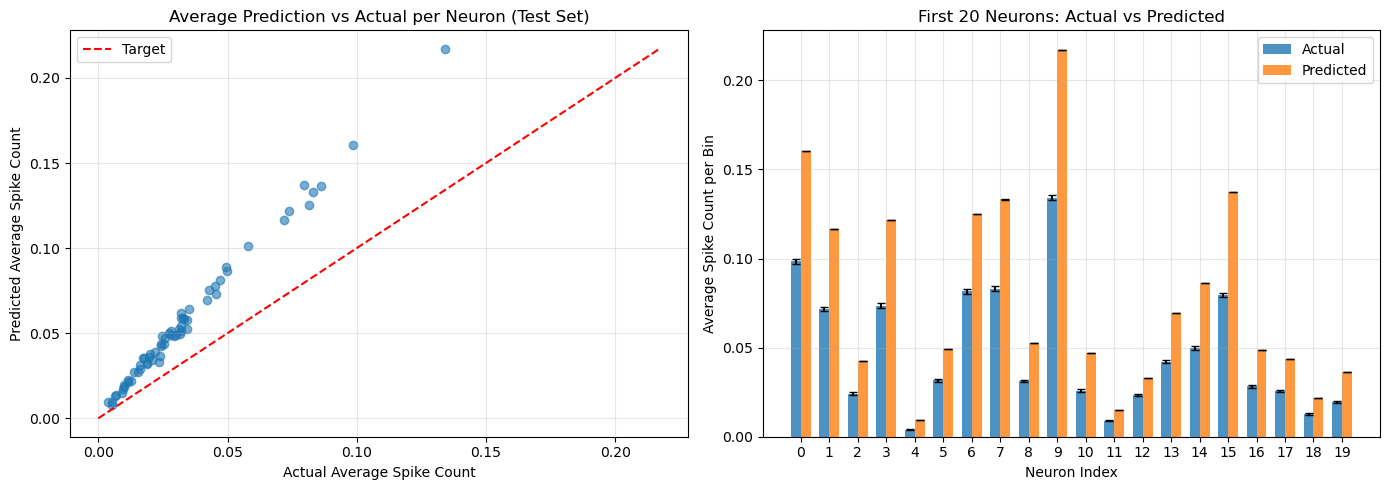

In [9]:
import matplotlib.pyplot as plt
from viz import plot_test_prediction_comparison

# =====================
# Evaluate on Test Set
# =====================
# Load best model
model.load_state_dict(torch.load(os.path.join(RUN_DIR, 'best_stim_spike_model.pt')))

test_loss, test_corr = validate(model, test_loader, criterion, device, weight_loss=WEIGHT_LOSS, sum_loss=SUM_LOSS)
print(f"Test Loss: {test_loss:.6f}")
print (f"Test corr: {test_corr: .6f}")

# Generate predictions on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        all_preds.append(preds.cpu())
        all_targets.append(batch_y)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print(f"Test predictions shape: {all_preds.shape}")
print(f"Test targets shape: {all_targets.shape}")

# =====================
# Visualize predictions aggregated by neuron
# =====================
fig, axes, corr, pval = plot_test_prediction_comparison(
    all_preds, all_targets, 
    savepath=os.path.join(RUN_DIR, 'test_prediction_comparison.png'),
    logger=logger
)
plt.show()

In [ ]:
from viz import analyze_pattern_responses_by_pattern_name

# Run the analysis on TEST set (oracle patterns)
pattern_names, pat_true, pat_pred, pat_counts = analyze_pattern_responses_by_pattern_name(model, test_dataset, device)

# Summary statistics
logging.info(f"\nPer-pattern analysis:")
print(f"  Patterns: {len(pattern_names)}")
print(f"  True response range: [{pat_true.min():.4f}, {pat_true.max():.4f}]")
print(f"  Pred response range: [{pat_pred.min():.4f}, {pat_pred.max():.4f}]")

Found 50 unique oracle patterns in test set
Samples per pattern: min=1100, max=1100, mean=1100.0

Per-pattern analysis:
  Patterns: 50
  True response range: [0.0000, 0.2670]
  Pred response range: [0.0074, 0.2275]


2026-02-02 09:34:15,170 - INFO - Pattern selectivity summary:
2026-02-02 09:34:15,170 - INFO -   Mean correlation across neurons: 0.1128
2026-02-02 09:34:15,171 - INFO -   Median correlation: 0.1323
2026-02-02 09:34:15,171 - INFO -   Neurons with r > 0.5: 0 / 63
2026-02-02 09:34:15,172 - INFO -   Neurons with r > 0.3: 4 / 63


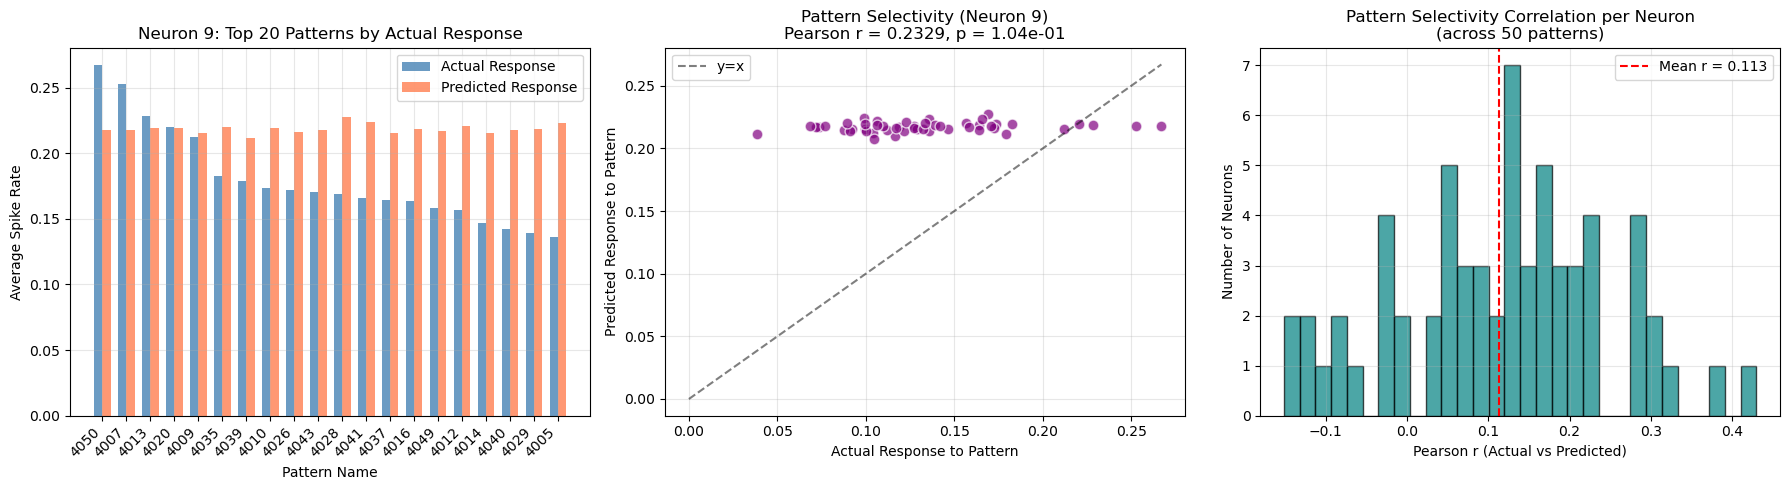

2026-02-02 09:34:15,301 - INFO - 
Pattern selectivity summary:
2026-02-02 09:34:15,301 - INFO -   Mean correlation across neurons: 0.1128
2026-02-02 09:34:15,302 - INFO -   Median correlation: 0.1323
2026-02-02 09:34:15,302 - INFO -   Neurons with r > 0.5: 0 / 63
2026-02-02 09:34:15,302 - INFO -   Neurons with r > 0.3: 4 / 63


In [11]:
from viz import plot_pattern_selectivity

# =====================
# Visualization: Pattern Selectivity Analysis
# =====================
fig, axes, neuron_correlations = plot_pattern_selectivity(
    pattern_names, pat_true, pat_pred,
    savepath=os.path.join(RUN_DIR, 'pattern_selectivity_analysis.png'),
    logger=logger
)
plt.show()

# Print summary
logging.info(f"\nPattern selectivity summary:")
logging.info(f"  Mean correlation across neurons: {np.mean(neuron_correlations):.4f}")
logging.info(f"  Median correlation: {np.median(neuron_correlations):.4f}")
logging.info(f"  Neurons with r > 0.5: {(neuron_correlations > 0.5).sum()} / {len(neuron_correlations)}")
logging.info(f"  Neurons with r > 0.3: {(neuron_correlations > 0.3).sum()} / {len(neuron_correlations)}")

In [12]:
# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, 3, :].cpu().numpy()}")
for i in range(min(1, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {sample_out[i, 3, :].cpu().numpy()}")



2026-02-02 09:34:15,328 - INFO - Sample model outputs (first batch):
2026-02-02 09:34:15,329 - INFO - Sample 0 target (neuron 4, all output bins): [0. 0. 0. 0. 0. 0.]
2026-02-02 09:34:15,330 - INFO - Sample 0 model output (neuron 4, all output bins): [-13.861098 -13.801943 -13.832915 -13.813467 -13.760774 -13.807453]


In [13]:
pattern_id = 4045
trial_idx = 10
chosen_pattern = pattern_df[(pattern_df['pattern_name'] == pattern_id) & (pattern_df['trial'] == trial_idx)]
max_time, min_time = chosen_pattern['pattern_end_timestamp'].max(), chosen_pattern['pattern_flag_start_timestamp'].min() # all values should be same anyways for these cols
spikes_during_pattern_trial= spikes_df[(spikes_df['timestamp'] <= max_time) & (spikes_df['timestamp'] >= min_time)]
print (min_time, max_time, max_time - min_time)
chosen_pattern

61040261 61101675 61414


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_flag_start_timestamp,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial,pattern_end_timestamp,pattern_duration
22791,0,61037263,4045,1.0,61040261,995,10,30.0,-1.0,True,10,61101675,61414
22792,0,61037263,4045,1.0,61040261,995,10,89.0,0.0,True,10,61101675,61414
22793,1,61039170,4045,1.0,61040261,995,10,30.0,1.0,True,10,61101675,61414
22794,1,61039170,4045,1.0,61040261,995,10,56.0,0.0,True,10,61101675,61414
22795,2,61040970,4045,1.0,61040261,995,10,NaN,NaN,True,10,61101675,61414
22796,3,61042770,4045,1.0,61040261,995,10,NaN,NaN,True,10,61101675,61414
22797,4,61044925,4045,1.0,61040261,995,10,33.0,-1.0,True,10,61101675,61414
22798,4,61044925,4045,1.0,61040261,995,10,90.0,0.0,True,10,61101675,61414
22799,5,61046848,4045,1.0,61040261,995,10,1.0,1.0,True,10,61101675,61414
22800,5,61046848,4045,1.0,61040261,995,10,34.0,0.0,True,10,61101675,61414


61414.0  duration frames


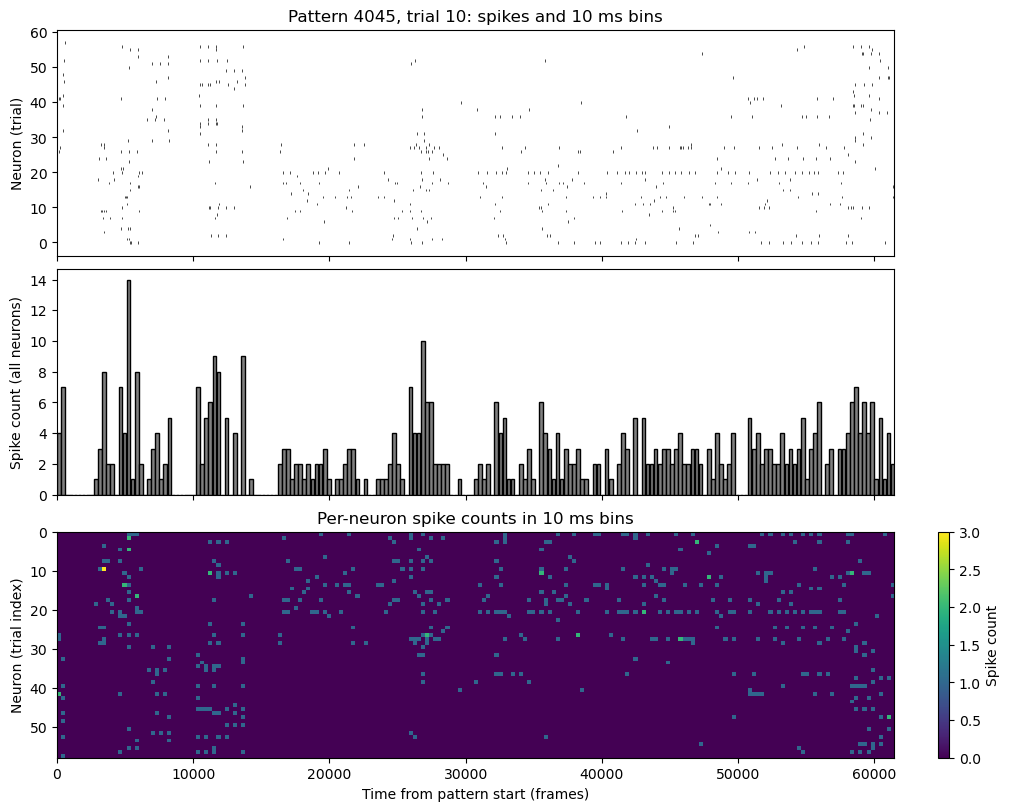

In [14]:
# Visualize spikes_during_pattern_trial: raster + binned at BIN_SIZE_MS
import numpy as np
import matplotlib.pyplot as plt
# Sort spikes for consistent plotting
trial_spikes = spikes_during_pattern_trial.sort_values(['neuron_id', 'timestamp'])

# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)


# Time relative to pattern start
t0 = min_time
times_rel = (trial_spikes['timestamp'].values - t0).astype(float)
neurons_rel = trial_spikes['neuron_id'].values

# Build per-neuron spike time lists for raster
unique_neurons_trial = np.sort(trial_spikes['neuron_id'].unique())
spike_times_per_neuron = [times_rel[neurons_rel == nid] for nid in unique_neurons_trial]

# Binning across all neurons using BIN_SIZE_FRAMES
duration_frames = float(max_time - min_time)
print (duration_frames, " duration frames")
if duration_frames <= 0 or np.abs(duration_frames - 60000) >= 3000: # something is wrong
    raise ValueError("max_time must be greater than min_time for binning.")

n_bins = int(np.ceil(duration_frames / BIN_SIZE_FRAMES))
# FIX: Use BIN_SIZE_FRAMES for the upper limit, not BIN_SIZE_MS
bin_edges = np.arange(0, (n_bins + 1) * BIN_SIZE_FRAMES, BIN_SIZE_FRAMES)
binned_counts, _ = np.histogram(times_rel, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# Per-neuron binned counts (same bins)
per_neuron_binned = []
for nid in unique_neurons_trial:
    neuron_times = times_rel[neurons_rel == nid]
    counts, _ = np.histogram(neuron_times, bins=bin_edges)
    per_neuron_binned.append(counts)
per_neuron_binned = np.stack(per_neuron_binned, axis=0)  # shape: (n_neurons_in_trial, n_bins)

fig, (ax_raster, ax_hist, ax_heat) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

# Raster plot (one row per neuron in this trial)
ax_raster.eventplot(
    spike_times_per_neuron,
    lineoffsets=np.arange(len(unique_neurons_trial)),
    linelengths=0.8,
    linewidths=0.5,
    color='black',
)
ax_raster.set_ylabel('Neuron (trial)')
ax_raster.set_title(f'Pattern {pattern_id}, trial {trial_idx}: spikes and {BIN_SIZE_MS} ms bins')
ax_raster.set_xlim(0, duration_frames)

# Binned spike counts (all neurons)
ax_hist.bar(
    bin_centers,
    binned_counts,
    width=BIN_SIZE_FRAMES * 0.9, # FIX: Width in frames
    align='center',
    color='gray',
    edgecolor='black',
)
ax_hist.set_ylabel('Spike count (all neurons)')
ax_hist.set_xlim(0, duration_frames)  # data recording is approx. variable 30 kHz

# Per-neuron bin counts heatmap
im = ax_heat.imshow(
    per_neuron_binned,
    aspect='auto',
    interpolation='nearest',
    extent=[0, n_bins * BIN_SIZE_FRAMES, len(unique_neurons_trial), 0], # FIX: Extent in frames
    cmap='viridis',
)
ax_heat.set_xlabel('Time from pattern start (frames)') # FIX: Label matches units
ax_heat.set_ylabel('Neuron (trial index)')
ax_heat.set_title(f'Per-neuron spike counts in {BIN_SIZE_MS} ms bins')
fig.colorbar(im, ax=ax_heat, label='Spike count')

plt.show()

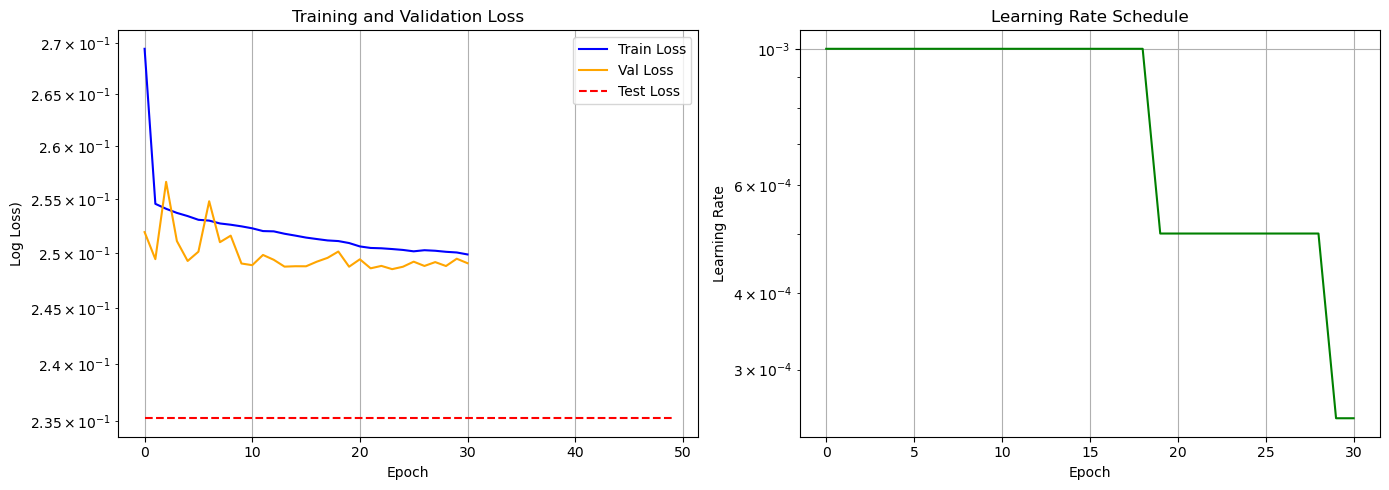

In [15]:
# =====================
# Plot Training History and Test Results
# =====================
if history is not None and len(history.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].plot(np.arange(NUM_EPOCHS), [test_loss]*NUM_EPOCHS, label='Test Loss', color='red', linestyle="--")

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Log Loss)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True)

    # Learning rate
    axes[1].plot(history['lr'], color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'training_history.png'), dpi=150)
    plt.show()
else:
    logger.warning("No training history available to plot")

In [16]:
from viz import plot_oracle_trials_by_pattern

# Extract visualization config
PATTERN_LIMIT = cfg.get('pattern_limit', 3)

# Loop through oracle patterns and save per-pattern figures for trials 0-19
out_base = os.path.join(RUN_DIR, 'oracle_trials_by_pattern')

plot_oracle_trials_by_pattern(
    model=model,
    test_dataset=test_dataset,
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    pattern_polarities=pattern_polarities,
    bin_size=BIN_SIZE_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    output_offset=OUTPUT_OFFSET,
    max_time_ms=MAX_TIME_MS,
    n_neurons=n_neurons,
    device=device,
    out_base=out_base,
    logger=logger,
    pattern_limit=PATTERN_LIMIT
)

2026-02-02 09:34:16,130 - INFO - Found 50 oracle patterns
2026-02-02 09:34:16,130 - INFO - Using bin_size=10ms, n_input_bins=1, n_output_bins=6, output_offset=0
2026-02-02 09:34:16,131 - INFO - Total bins: 60, Valid input positions: 0 to 54


oracle patterns:  [4033 4017 4028 4003 4025 4004 4040 4038 4022 4034 4030 4031 4005 4010
 4039 4002 4026 4047 4036 4020 4049 4029 4044 4012 4037 4045 4014 4015
 4023 4048 4011 4019 4050 4018 4001 4032 4021 4046 4006 4013 4027 4016
 4043 4041 4008 4007 4042 4009 4024 4035]


2026-02-02 09:34:16,470 - INFO - Saved pattern 4033 trial 0 figure to results/binned_2026-02-02_09-09-36/oracle_trials_by_pattern/pattern_4033/trial_00_timing_0.jpg
2026-02-02 09:34:22,430 - INFO - Completed pattern 4033 (1/50)
2026-02-02 09:34:22,740 - INFO - Saved pattern 4017 trial 0 figure to results/binned_2026-02-02_09-09-36/oracle_trials_by_pattern/pattern_4017/trial_00_timing_1.jpg
2026-02-02 09:34:28,775 - INFO - Completed pattern 4017 (2/50)
2026-02-02 09:34:29,081 - INFO - Saved pattern 4028 trial 0 figure to results/binned_2026-02-02_09-09-36/oracle_trials_by_pattern/pattern_4028/trial_00_timing_2.jpg
2026-02-02 09:34:34,973 - INFO - Completed pattern 4028 (3/50)
2026-02-02 09:34:34,974 - INFO - Pattern limit of 3 reached, stopping.
2026-02-02 09:34:34,974 - INFO - Saved all oracle pattern figures to results/binned_2026-02-02_09-09-36/oracle_trials_by_pattern


In [17]:
# Test forward pass after training
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    sample_out = model(sample_x)

logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

assert sample_out.shape[1:] == sample_y.shape[1:], f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")

# Show some sample outputs; labels are batch x neurons x output_bins
logger.info("Sample model outputs (first batch):")
neuron = 1
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} target (neuron 4, all output bins): {sample_y[i, neuron, :].cpu().numpy()}")
for i in range(min(5, sample_out.shape[0])):
    logger.info(f"Sample {i} model output (neuron 4, all output bins): {np.exp(sample_out[i, neuron, :].cpu().numpy())}")


2026-02-02 09:34:35,013 - INFO - Input shape: torch.Size([128, 42, 1]), dtype: torch.int64
2026-02-02 09:34:35,014 - INFO - Output shape: torch.Size([128, 63, 6])
2026-02-02 09:34:35,014 - INFO - Target shape: torch.Size([128, 63, 6])
2026-02-02 09:34:35,015 - INFO - ✓ Output and target shapes match!
2026-02-02 09:34:35,015 - INFO - Sample model outputs (first batch):
2026-02-02 09:34:35,015 - INFO - Sample 0 target (neuron 4, all output bins): [0. 0. 0. 0. 0. 0.]
2026-02-02 09:34:35,016 - INFO - Sample 1 target (neuron 4, all output bins): [0. 0. 0. 0. 0. 0.]
2026-02-02 09:34:35,016 - INFO - Sample 2 target (neuron 4, all output bins): [0. 0. 0. 1. 0. 0.]
2026-02-02 09:34:35,017 - INFO - Sample 3 target (neuron 4, all output bins): [0. 0. 0. 1. 0. 0.]
2026-02-02 09:34:35,018 - INFO - Sample 4 target (neuron 4, all output bins): [0. 0. 1. 0. 0. 0.]
2026-02-02 09:34:35,020 - INFO - Sample 0 model output (neuron 4, all output bins): [0.11042995 0.11658723 0.10706545 0.11917152 0.12169801